<a href="https://colab.research.google.com/github/GustavoEmanuel901/lainfs-pense-repository/blob/Mozart/Pense.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GerenciadorArquivos
Objetivo: Responsável pelo Input/Output (E/S) de dados entre o ambiente do Google Colab e o Google Drive.

Principais Métodos:

load_data(separador, codificacao): Faz o download seguro do arquivo bruto armazenado na nuvem usando a biblioteca gdown, carrega em um DataFrame Pandas e apaga o lixo temporário do disco local para poupar armazenamento.

salvar_no_drive(dataframe, nome_arquivo_final): Realiza a montagem do Google Drive (drive.mount) e exporta o resultado final em formato UTF-8 para a pasta de destino configurada (ex: MyDrive/lainfs/).

In [ ]:
%%writefile gerenciador_de_arquivos.py
import pandas as pd
import gdown
import os
from google.colab import drive

class GerenciadorArquivos:
    def __init__(self, fileId):
        self.file_id = fileId
        self.url = f'https://drive.google.com/uc?id={fileId}'
        self.output_name = 'pense_temp.csv'
        self.df = None

    def load_data(self, separador=',', codificacao='latin1'):
        """Permite configurar o separador e o encoding dinamicamente"""
        try:
            print(f"\nBaixando arquivo do Google Drive...")
            gdown.download(self.url, self.output_name, quiet=True)

            print("Lendo o arquivo baixado...")
            self.df = pd.read_csv(self.output_name, sep=separador, encoding=codificacao)
            print("Carga concluída com sucesso!")

            if os.path.exists(self.output_name):
                os.remove(self.output_name)

            return self.df
        except Exception as e:
            print(f'Erro interno no gerenciador_de_arquivos.py: {e}')
            if os.path.exists(self.output_name):
                os.remove(self.output_name)
            return None

    def salvar_no_drive(self, dataframe, nome_arquivo_final):
        try:
            print("\n[Escrita] Conectando ao seu Google Drive pessoal...")
            drive.mount('/content/drive')
            caminho_salvamento = f'/content/drive/MyDrive/lainfs/{nome_arquivo_final}'
            dataframe.to_csv(caminho_salvamento, sep=',', index=False, encoding='utf-8')
            print("Salvo arquivo")
        except Exception as e:
            print(f'Erro ao salvar o arquivo no Drive: {e}')

Overwriting gerenciador_de_arquivos.py


Objetivo: Realizar a engenharia de atributos estatísticos (Outliers e Escalonamento).Principais Métodos:sinalizar_outliers_iqr(df, col): Aplica o método do Intervalo Interquartil ($IQR = Q_3 - Q_1$) para detectar respostas extremas. Cria uma nova coluna binária [coluna]_outlier onde 1 representa um outlier e 0 um dado normal.normalizar_colunas_generico(df, colunas): Aplica a normalização Min-Max((x'): é o valor normalizado.(x): é o valor original.(x_{min}): é o menor valor presente no conjunto de dados.(x_{max}): é o maior valor presente no conjunto de dados.), espremendo os valores numéricos para uma escala estrita entre 0.0 e 1.0 na coluna [coluna]_norm. Outliers são desconsiderados no cálculo do mínimo e máximo para evitar distorções na escala.gerar_perfil_outliers(df, col_alvo, col_perfil): Cruza o subgrupo de estudantes identificados como outliers com as variáveis de perfil sociodemográfico para entender o comportamento de extremos na amostra.

In [ ]:
%%writefile pense_estatistica.py
import pandas as pd

class PenseEstatistica:
    def sinalizar_outliers_iqr(self, df, col):
        df_result = df.copy()
        valores = pd.to_numeric(df_result[col], errors='coerce').dropna()

        if len(valores) == 0:
            df_result[f'{col}_outlier'] = 0
            return df_result

        q1 = valores.quantile(0.25)
        q3 = valores.quantile(0.75)
        iqr = q3 - q1

        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        df_result[f'{col}_outlier'] = 0

        condicao_outlier = (
            (pd.to_numeric(df_result[col], errors='coerce') < limite_inferior) |
            (pd.to_numeric(df_result[col], errors='coerce') > limite_superior)
        )
        df_result.loc[condicao_outlier, f'{col}_outlier'] = 1
        return df_result

    def normalizar_colunas_generico(self, df, colunas):
        df_norm = df.copy()

        for col in colunas:
            if col in df_norm.columns:
                df_norm[col] = pd.to_numeric(df_norm[col], errors='coerce')

                if f'{col}_outlier' in df_norm.columns:
                    dados_referencia = df_norm[df_norm[f'{col}_outlier'] == 0][col]
                else:
                    dados_referencia = df_norm[col].dropna()

                v_min = dados_referencia.min()
                v_max = dados_referencia.max()

                if pd.notna(v_min) and pd.notna(v_max) and (v_max - v_min) != 0:
                    df_norm[f'{col}_norm'] = (df_norm[col] - v_min) / (v_max - v_min)
                    print(f" [Estatística] Coluna '{col}' normalizada como '{col}_norm'.")
                else:
                    df_norm[f'{col}_norm'] = 0.0

        return df_norm

    def gerar_perfil_outliers(self, df, col_alvo, col_perfil):
        col_outlier = f'{col_alvo}_outlier'

        if col_outlier not in df.columns:
            return

        # Filtra a tabela apenas com a minoria que teve comportamentos extremos
        df_outliers = df[df[col_outlier] == 1].copy()
        total_outliers = len(df_outliers)

        print(f" INVESTIGAÇÃO DE PERFIL: OUTLIERS DE {col_alvo}")
        print(f"Total de estudantes neste grupo extremo: {total_outliers}")


        if total_outliers == 0:
            print("Nenhum outlier para analisar.")
            return

        for col in col_perfil:
            if col in df_outliers.columns:
                print(f"\n>> Cruzamento com a variável: {col}")

                # Calcula a quantidade e a porcentagem exata dentro desse grupo
                contagem = df_outliers[col].value_counts(dropna=False)
                porcentagem = df_outliers[col].value_counts(normalize=True, dropna=False) * 100

                # Monta um relatório limpo
                resumo = pd.DataFrame({
                    'Quantidade': contagem,
                    '% do Grupo': porcentagem.round(1)
                })

                # Exibe a tabela formatada
                print(resumo.to_string())


Overwriting pense_estatistica.py


Objetivo: Geração automática de gráficos de análise exploratória.

Principais Métodos:

plotar_boxplot(): Gera gráficos de caixa destacando a mediana, quartis e pontos vermelhos que representam os outliers.

plotar_histograma(): Cria histogramas de distribuição de frequência acompanhados da linha de densidade estimada (KDE).

In [ ]:
%%writefile pense_visualizer.py
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

class PenseVisualizer:
    def __init__(self):
        sns.set_theme(style="whitegrid")

    def plotar_boxplot(self, df, coluna, titulo):
        """Plota um Boxplot com os outliers marcados em vermelho para diagnóstico"""
        plt.figure(figsize=(8, 3))
        dados_plot = pd.to_numeric(df[coluna], errors='coerce').dropna()

        if len(dados_plot) == 0:
            return

        sns.boxplot(x=dados_plot, color="#5f9ea0", flierprops={"markerfacecolor":"red", "marker":"o"})
        plt.title(titulo, fontsize=11, fontweight='bold', pad=10)
        plt.xlabel(f"Escala numérica da variável: {coluna}")
        plt.show()

    def plotar_histograma(self, df, coluna, titulo):
        plt.figure(figsize=(8, 4))
        dados_plot = pd.to_numeric(df[coluna], errors='coerce').dropna()

        if len(dados_plot) == 0:
            return

        sns.histplot(dados_plot, kde=True, color="#d2b48c", bins=15)
        plt.title(titulo, fontsize=11, fontweight='bold', pad=10)
        plt.xlabel(f"Valores da variável: {coluna}")
        plt.ylabel("Frequência de Respostas")
        plt.show()

    def plotar_todos_boxplots(self, df, colunas, dicionario):
        """Gera uma única figura contendo os boxplots de todas as variáveis selecionadas."""
        import math

        if not colunas:
            print("Nenhuma coluna disponível para gerar boxplots.")
            return

        # Define a estrutura da grade (máximo de 3 colunas por linha para não espremer)
        num_cols_grade = 3
        num_linhas_grade = math.ceil(len(colunas) / num_cols_grade)

        # Cria a figura com o tamanho proporcional à quantidade de gráficos
        fig, axes = plt.subplots(num_linhas_grade, num_cols_grade, figsize=(16, 4 * num_linhas_grade))

        # Garante que 'axes' seja uma lista/array plano, mesmo se houver apenas 1 linha ou 1 coluna
        if num_linhas_grade == 1 and num_cols_grade == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for i, col in enumerate(colunas):
            dados_plot = pd.to_numeric(df[col], errors='coerce').dropna()

            # Se a coluna tiver dados, plota no sub-gráfico correspondente
            if len(dados_plot) > 0:
                sns.boxplot(x=dados_plot, ax=axes[i], color="#5f9ea0",
                            flierprops={"markerfacecolor":"red", "marker":"o"})

                # Pega o significado no dicionário para colocar como legenda/título secundário
                significado = dicionario.obter_significado(col)
                # Corta o texto se for muito longo para não quebrar o layout
                significado_curto = significado[:40] + "..." if len(significado) > 40 else significado

                # Configura o título do sub-gráfico com o código e a legenda explicativa
                axes[i].set_title(f"Variável: {col}\n({significado_curto})", fontsize=10, fontweight='bold')
                axes[i].set_xlabel("Escala de Respostas")
            else:
                axes[i].set_title(f"{col} (Sem dados)", fontsize=10)

        # Desliga os sub-gráficos vazios que sobrarem na grade
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        # Ajusta o espaçamento para os títulos não encostarem uns nos outros
        plt.tight_layout()
        plt.show()

Overwriting pense_visualizer.py


Objetivo: Atua como um inspetor visual rápido de sanidade dos dados carregados.

Principais Métodos:

exibir_dados(): Mostra as dimensões da tabela (shape) e renderiza uma amostra com as primeiras e últimas 50 linhas na tela do notebook.

In [ ]:
%%writefile pense_dados.py
from IPython.display import display

class PenseDados:
    def __init__(self, dataframe):
        self.df = dataframe

    def exebir_dados(self):
        print("\n=== VISUALIZANDO ESTRUTURA DA TABELA ===")
        print(f"Formato Atual (Linhas, Colunas): {self.df.shape}")
        val = 5
        print(f'Amostra das {val} primeiras linhas:')
        display(self.df.head(val))
        print(f"Amostra da {val} ultima linhas")
        display(self.df.tail(val))

Overwriting pense_dados.py


Objetivo: Centraliza as regras de negócio e a higienização dos dados do IBGE.

Principais Métodos:

filtrar_perfil(blocos): Cria uma whitelist de variáveis sociodemográficas essenciais (Idade, Sexo, Raça, Escolaridade da Mãe) chamadas de perfil_desejado. Reduz o tamanho da base mantendo apenas a geografia, as variáveis de perfil e os blocos específicos de perguntas escolhidos para a rodada, otimizando o uso da memória RAM.

padronizar_categorias_base(): Agrupa categorias conforme o padrão do laboratório. Junta escolas municipais e estaduais sob o rótulo de "Escola Pública" (1) e separa as privadas (0), além de normalizar anos escolares e dados demográficos.

tratar_valores_nulos(): Mapeia e substitui códigos de erro, saltos de questionário ou não-respostas do IBGE (como -1, -2, 9, 99) pelo valor nulo real do Pandas (pd.NA). Isso impede que cálculos de média e outliers sejam distorcidos por esses códigos numéricos elevados.

In [ ]:
%%writefile pense_limpeza.py
import pandas as pd

class PenseLimpeza:
    def __init__(self, dataframe):
        self.df = dataframe.copy()

    def filtrar_perfil(self, blocos):
        col_base = ['REGIAO', 'UF', 'ESFERA', 'ANO_TURMA', 'TIPO_MUNIC']

        perfil_desejado = [
            'B01001A', 'B01003', 'B01002', 'B01021A', 'B01006', 'B01007'
        ]

        col_perfil = [
            col for col in self.df.columns
            if col.upper() in perfil_desejado
        ]

        prefixo_upper = [p.upper() for p in blocos]
        col_perguntas = [
            col for col in self.df.columns
            if any(col.upper().startswith(p) for p in prefixo_upper)
            and col not in col_perfil
        ]

        col_final = [c for c in (col_base + col_perfil + col_perguntas) if c in self.df.columns]
        self.df = self.df[col_final]

        return self

    def padronizar_categorias_base(self):

        if 'ESFERA' in self.df.columns:
            self.df['ESFERA'] = pd.to_numeric(self.df['ESFERA'], errors='coerce')
            self.df['ESFERA'] = self.df['ESFERA'].replace({4: 0, 2: 1, 3: 1})
            #2: Estadual
            #3: Municipal
            #4: Privada

        if 'ANO_TURMA' in self.df.columns:
            self.df['ANO_TURMA'] = pd.to_numeric(self.df['ANO_TURMA'], errors='coerce')
            self.df['ANO_TURMA'] = self.df['ANO_TURMA'].replace({
                1: '7º Ano EF',
                2: '8º Ano EF',
                3: '9º Ano EF',
                4: '1º Ano EM',
                5: '2º Ano EM',
                6: '3º Ano EM',
                7: '1º Ano Técnico',
                8: '2º Ano Técnico',
                9: '3º Ano Técnico',
                10: '1º Ano Magistério',
                11: '2º Ano Magistério',
                12: '3º Ano Magistério'
            })

        if 'B01001A' in self.df.columns:
            self.df['B01001A'] = pd.to_numeric(self.df['B01001A'], errors='coerce').replace(9, 3) #1:masculino | 2:feminino | 9:nao informado

        if 'B01003' in self.df.columns:
            self.df['B01003'] = pd.to_numeric(self.df['B01003'], errors='coerce')
            self.df = self.df[self.df['B01003'] != 9] #idade

        if 'B01002' in self.df.columns:
            self.df['B01002'] = pd.to_numeric(self.df['B01002'], errors='coerce').replace(9, 4) #1: Branca | 2: Preta | 3: Amarela | 4: Parda | 5: Indígena | 9:Nao informado


        if 'B01006' in self.df.columns:
            self.df['B01006'] = pd.to_numeric(self.df['B01006'], errors='coerce').replace(9, 3) #1 significa Sim, 2 significa Não e 9 é Não informado

        if 'B01007' in self.df.columns:
            self.df['B01007'] = pd.to_numeric(self.df['B01007'], errors='coerce').replace(9, 3) #1 e 2 indicam os níveis de instrução estudados, e 9 significa "Não sabe/Não informado".

        return self

    def tratar_valores_nulos(self):
        col_perguntas = [col for col in self.df.columns if col.upper().startswith('B')]

        for col in col_perguntas:
            if col in self.df.columns:
                self.df[col] = self.df[col].replace([-1.0, -2.0, 9.0, 99.0, -1, -2, 9, 99], pd.NA)
        return self

    def obter_dados_tratados(self):
        return self.df

Overwriting pense_limpeza.py


Objetivo: Traduzir os códigos técnicos das colunas do IBGE para texto legível.

Principais Métodos:

obter_significado(codigo_variavel): Busca o código da pergunta (ex: B07001) no dicionário oficial anexado e retorna a pergunta real feita ao estudante (ex: "Com que frequência você consome feijão?").

In [ ]:
%%writefile pense_dicionario.py
import pandas as pd

class PenseDicionario:
    def __init__(self, dataframe):
        self.df = dataframe.copy()

    def obter_significado(self, codigo_variavel):
        if self.df is None or self.df.empty:
            return None

        col_codigo = self.df.columns[0]
        col_descricao = self.df.columns[1]

        result = self.df[
            self.df[col_codigo].astype(str).str.upper() == str(codigo_variavel).upper()
        ]

        if not result.empty:
            return result.iloc[0][col_descricao]
        return "Código não localizado neste arquivo de dicionário."

Overwriting pense_dicionario.py


Objetivo: Registrar e documentar a execução do pipeline de forma automatizada.

Principais Métodos:

registrar_visao_geral(): Anota o impacto volumétrico da limpeza (linhas/colunas antes e depois).

registrar_variavel(): Adiciona uma seção técnica detalhando máximos, mínimos e a quantidade de outliers gerados para cada variável processada.

salvar_relatorio(nome_arquivo): Exporta o compilado de anotações em um arquivo estruturado Markdown (.md).

In [ ]:
%%writefile pense_relatorio.py
import pandas as pd
import os

class PenseRelatorio:
    def __init__(self):
        self.linhas = []
        self.linhas.append("#  Relatório Automatizado de Processamento e Estatística — LAINFS\n")
        self.linhas.append("Este relatório foi gerado dinamicamente pelo pipeline de dados da **PeNSE 2019**.\n")
        self.linhas.append("---\n")

    def registrar_visao_geral(self, blocos, df_antes, df_depois):
        """Anota as informações de redução e filtros do dataframe"""
        self.linhas.append("## 1. Visão Geral do Dataset\n")
        self.linhas.append(f"* **Blocos Temáticos Analisados:** {', '.join(blocos)}")
        self.linhas.append(f"* **Volume de Dados Inicial (Bruto):** {df_antes.shape[0]:,} linhas | {df_antes.shape[1]} colunas")
        self.linhas.append(f"* **Volume de Dados Final (Limpo):** {df_depois.shape[0]:,} linhas | {df_depois.shape[1]} colunas")
        self.linhas.append("* **Tratamento de Omissões:** Códigos como `-1` e `99` foram convertidos para Nulos (pd.NA).\n")
        self.linhas.append("---\n")
        self.linhas.append("## 2. Diagnóstico Estatístico das Variáveis\n")

    def registrar_variavel(self, df, col_real, significado):
        """Para cada variável analisada, anota os outliers e o range estatístico"""

        # Puxa os dados reais ignorando os vazios
        dados = pd.to_numeric(df[col_real], errors='coerce').dropna()
        v_min = dados.min()
        v_max = dados.max()

        # Conta quantos outliers foram pegos na nossa rede (quem foi marcado com 1)
        col_outlier = f'{col_real}_outlier'
        if col_outlier in df.columns:
            total_outliers = (df[col_outlier] == 1).sum()
        else:
            total_outliers = "Não calculado"

        # Escreve o parágrafo dessa variável no relatório
        self.linhas.append(f"###  Variável: `{col_real}`")
        self.linhas.append(f"* **Significado do IBGE:** *{significado}*")
        self.linhas.append(f"* **Distribuição dos Dados:** Valores variaram de **{v_min}** a **{v_max}**.")
        self.linhas.append(f"* **Outliers Extremos (Fórmula IQR):** **{total_outliers} estudantes** detectados fora da curva.")
        self.linhas.append(f"* **Status:** Escala Min-Max gerada como `{col_real}_norm`.\n")

    def salvar_relatorio(self, nome_arquivo="Relatorio_Analise_PeNSE.md"):
        """Junta todas as linhas e salva em um arquivo físico legível no notebook"""
        texto_final = "\n".join(self.linhas)

        with open(nome_arquivo, "w", encoding="utf-8") as f:
            f.write(texto_final)

        print(f"\n SUCESSO: Relatório estatístico automatizado salvo como '{nome_arquivo}'.")
        print("Para visualizar o relatório no Colab, basta clicar 2x nele na aba de arquivos (ícone de pasta à esquerda).")

Overwriting pense_relatorio.py


In [ ]:
import sys
for mod in ['gerenciador_de_arquivos', 'pense_dados', 'pense_limpeza', 'pense_estatistica', 'pense_visualizer','pense_dicionario','pense_relatorio']:
    if mod in sys.modules: del sys.modules[mod]

Como Executar o Pipeline
Para rodar uma nova análise, abra o script principal e configure as variáveis de controle no bloco final:

Python
1. Defina o ID do arquivo bruto que está no seu Google Drive
file_id_pense = 'SEU_ID_DO_ARQUIVO_AQUI'

 2. Defina quais blocos você quer processar NESTA rodada (ex: Bloco B07)
blocos_para_analise = ['B07']

 3. Instancie o gerenciador e execute o pipeline
gerenciador = GerenciadorArquivos(file_id_pense)
... o restante do script executará a esteira automaticamente


Baixando arquivo do Google Drive...
Lendo o arquivo baixado...
Carga concluída com sucesso!

Baixando arquivo do Google Drive...
Lendo o arquivo baixado...
Carga concluída com sucesso!

--- EXECUTANDO LIMPEZA E PADRONIZAÇÃO ---

 Analisando variável: B07001


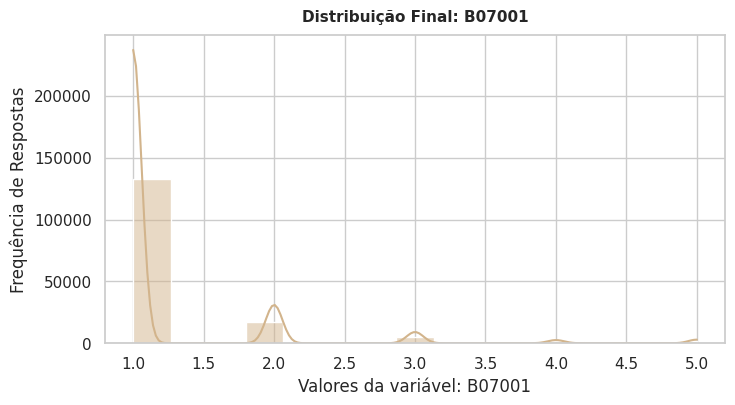

 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B07001
Total de estudantes neste grupo extremo: 25521

>> Cruzamento com a variável: ESFERA
        Quantidade  % do Grupo
ESFERA                        
1.0          17231        67.5
0.0           8290        32.5

>> Cruzamento com a variável: ANO_TURMA
                   Quantidade  % do Grupo
ANO_TURMA                                
7º Ano EF                5101        20.0
1º Ano EM                4617        18.1
8º Ano EF                3966        15.5
3º Ano EM                3866        15.1
2º Ano EM                3775        14.8
9º Ano EF                3757        14.7
1º Ano Técnico            194         0.8
3º Ano Técnico            122         0.5
2º Ano Técnico            121         0.5
2º Ano Magistério           2         0.0

>> Cruzamento com a variável: B01001A
         Quantidade  % do Grupo
B01001A                        
1.0           13717        53.7
2.0           11721        45.9
3.0              83         0.3

>>

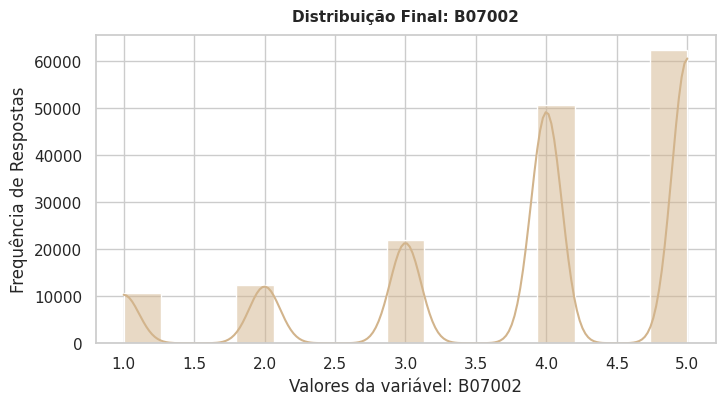

 [Estatística] Coluna 'B07002' normalizada como 'B07002_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B07002
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B07004


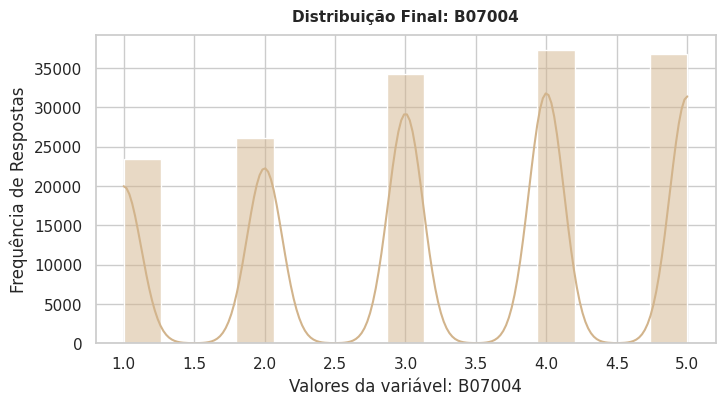

 [Estatística] Coluna 'B07004' normalizada como 'B07004_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B07004
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B07006


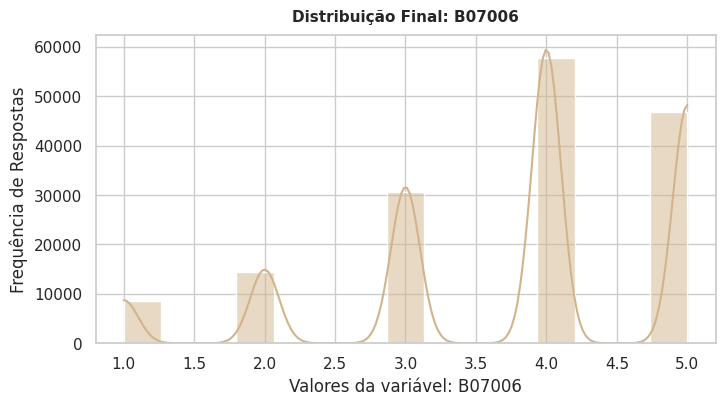

 [Estatística] Coluna 'B07006' normalizada como 'B07006_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B07006
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B07007A


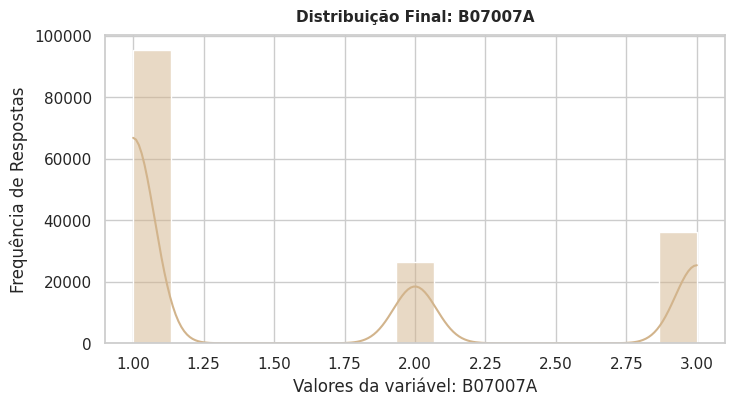

 [Estatística] Coluna 'B07007A' normalizada como 'B07007A_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B07007A
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B07008


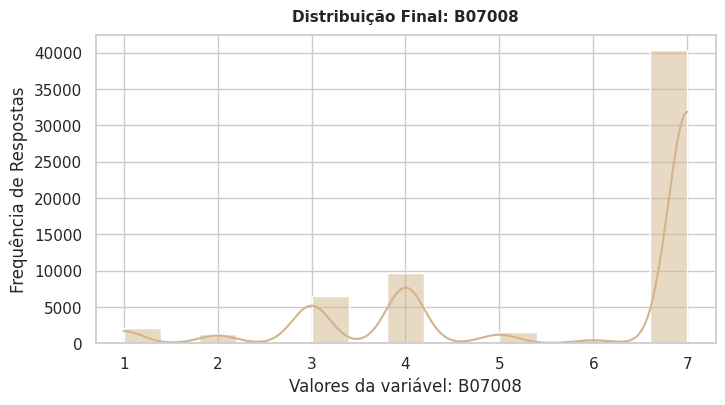

 [Estatística] Coluna 'B07008' normalizada como 'B07008_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B07008
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B07011


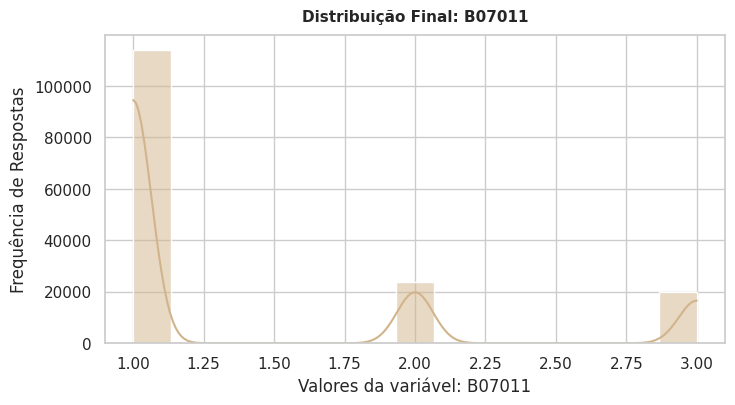

 [Estatística] Coluna 'B07011' normalizada como 'B07011_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B07011
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B07012


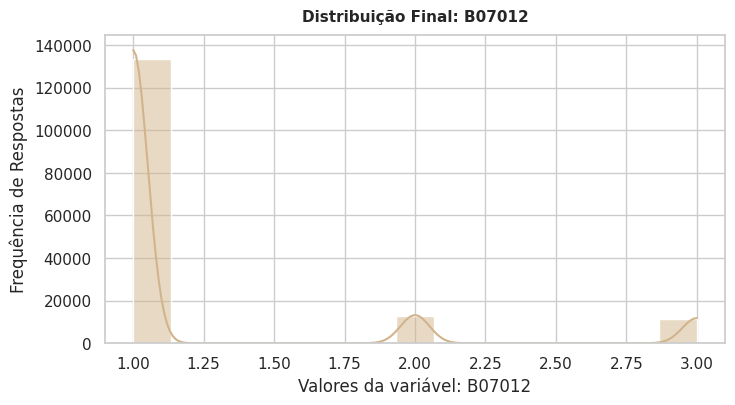

 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B07012
Total de estudantes neste grupo extremo: 24270

>> Cruzamento com a variável: ESFERA
        Quantidade  % do Grupo
ESFERA                        
0.0          12859        53.0
1.0          11411        47.0

>> Cruzamento com a variável: ANO_TURMA
                   Quantidade  % do Grupo
ANO_TURMA                                
7º Ano EF                6747        27.8
8º Ano EF                5577        23.0
9º Ano EF                4661        19.2
1º Ano EM                3434        14.1
2º Ano EM                2049         8.4
3º Ano EM                1505         6.2
1º Ano Técnico            148         0.6
2º Ano Técnico             83         0.3
3º Ano Técnico             63         0.3
2º Ano Magistério           2         0.0
3º Ano Magistério           1         0.0

>> Cruzamento com a variável: B01001A
         Quantidade  % do Grupo
B01001A                        
1.0           14632        60.3
2.0            9572      

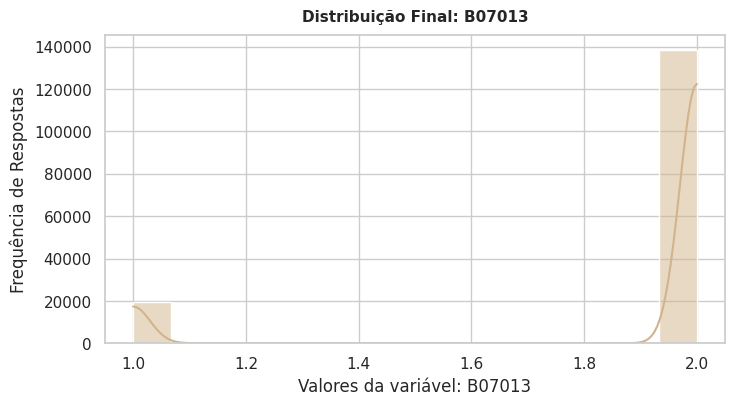

 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B07013
Total de estudantes neste grupo extremo: 19605

>> Cruzamento com a variável: ESFERA
        Quantidade  % do Grupo
ESFERA                        
1.0          10908        55.6
0.0           8697        44.4

>> Cruzamento com a variável: ANO_TURMA
                   Quantidade  % do Grupo
ANO_TURMA                                
9º Ano EF                3658        18.7
8º Ano EF                3646        18.6
1º Ano EM                3636        18.5
7º Ano EF                3562        18.2
2º Ano EM                2569        13.1
3º Ano EM                2266        11.6
1º Ano Técnico            152         0.8
3º Ano Técnico             58         0.3
2º Ano Técnico             56         0.3
2º Ano Magistério           2         0.0

>> Cruzamento com a variável: B01001A
         Quantidade  % do Grupo
B01001A                        
2.0           11955        61.0
1.0            7580        38.7
3.0              70         0.4

>>

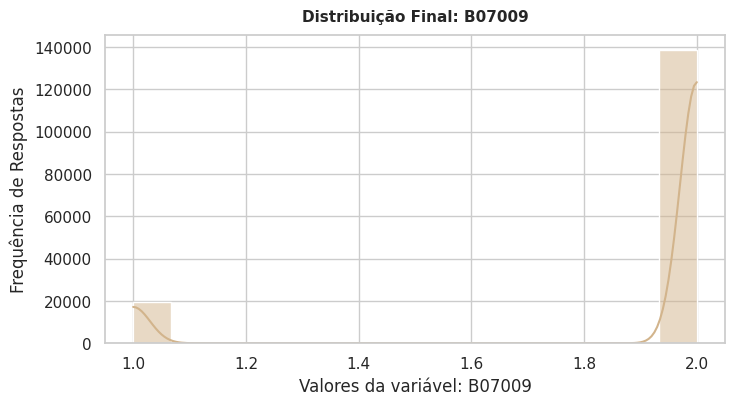

 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B07009
Total de estudantes neste grupo extremo: 19301

>> Cruzamento com a variável: ESFERA
        Quantidade  % do Grupo
ESFERA                        
1.0           9822        50.9
0.0           9479        49.1

>> Cruzamento com a variável: ANO_TURMA
                   Quantidade  % do Grupo
ANO_TURMA                                
7º Ano EF                3795        19.7
8º Ano EF                3728        19.3
9º Ano EF                3555        18.4
1º Ano EM                3393        17.6
2º Ano EM                2403        12.5
3º Ano EM                2137        11.1
1º Ano Técnico            129         0.7
2º Ano Técnico             97         0.5
3º Ano Técnico             61         0.3
2º Ano Magistério           2         0.0
3º Ano Magistério           1         0.0

>> Cruzamento com a variável: B01001A
         Quantidade  % do Grupo
B01001A                        
1.0           11633        60.3
2.0            7607      

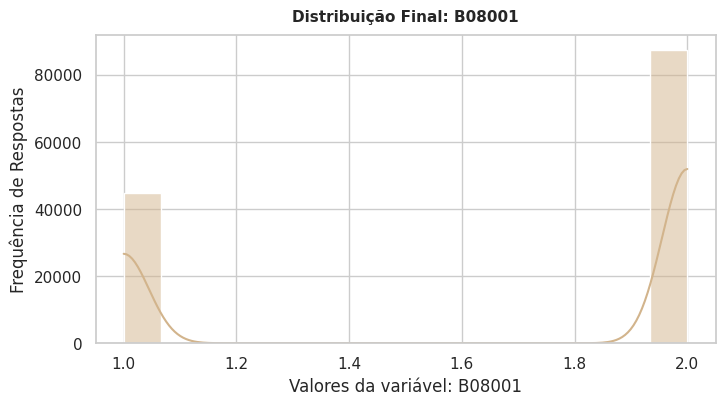

 [Estatística] Coluna 'B08001' normalizada como 'B08001_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B08001
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B08002


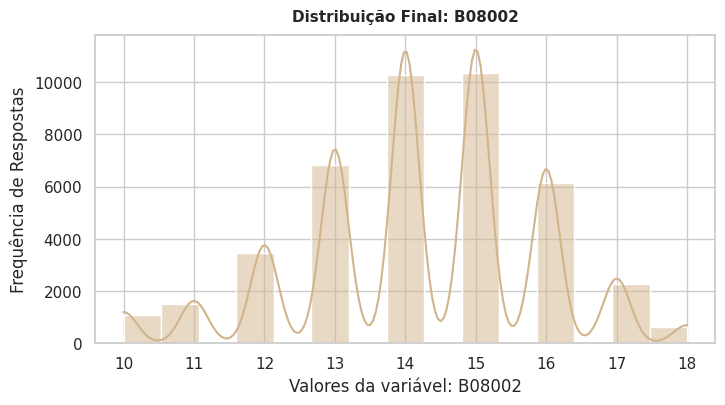

 [Estatística] Coluna 'B08002' normalizada como 'B08002_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B08002
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B08011A


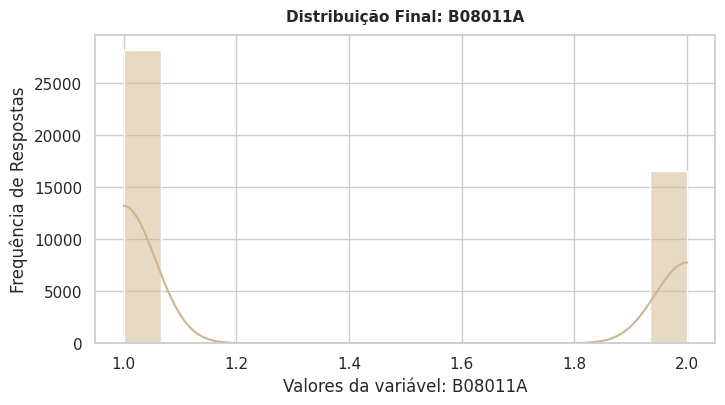

 [Estatística] Coluna 'B08011A' normalizada como 'B08011A_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B08011A
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B08006A


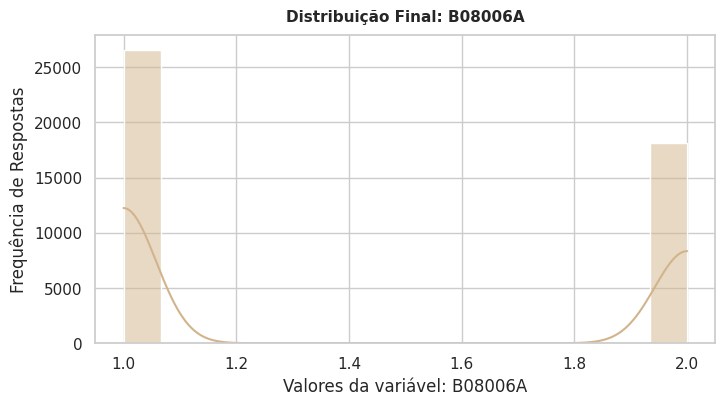

 [Estatística] Coluna 'B08006A' normalizada como 'B08006A_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B08006A
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B08014


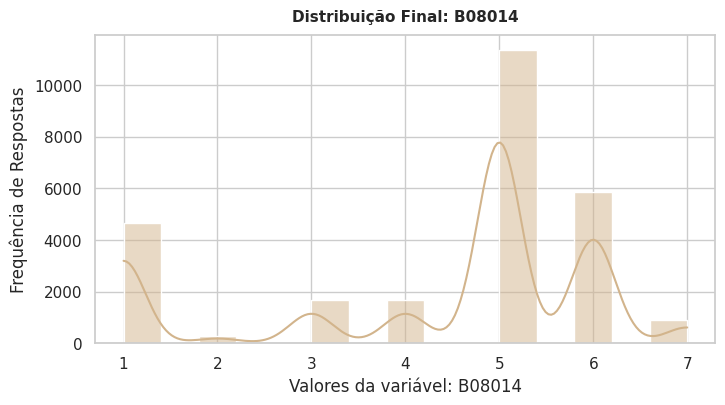

 [Estatística] Coluna 'B08014' normalizada como 'B08014_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B08014
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B08007


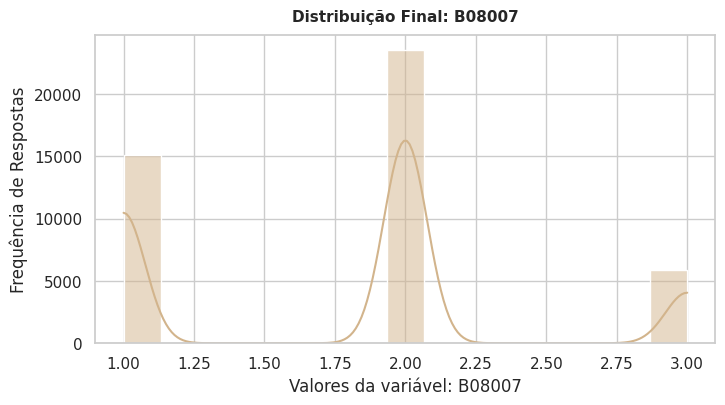

 [Estatística] Coluna 'B08007' normalizada como 'B08007_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B08007
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B08012A


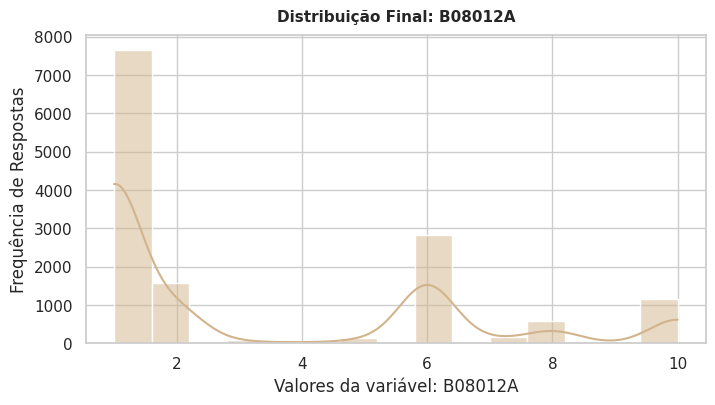

 [Estatística] Coluna 'B08012A' normalizada como 'B08012A_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B08012A
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B08015


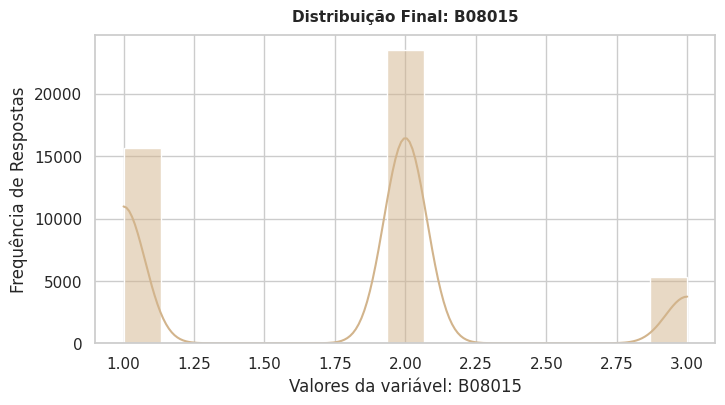

 [Estatística] Coluna 'B08015' normalizada como 'B08015_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B08015
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B08016


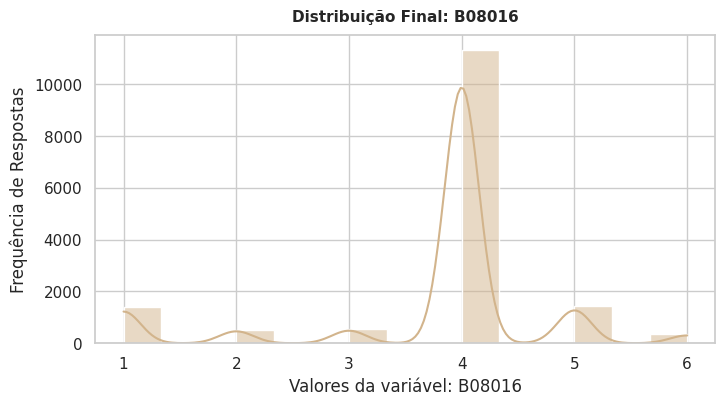

 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B08016
Total de estudantes neste grupo extremo: 4284

>> Cruzamento com a variável: ESFERA
        Quantidade  % do Grupo
ESFERA                        
1.0           2936        68.5
0.0           1348        31.5

>> Cruzamento com a variável: ANO_TURMA
                   Quantidade  % do Grupo
ANO_TURMA                                
1º Ano EM                1067        24.9
3º Ano EM                 975        22.8
2º Ano EM                 927        21.6
9º Ano EF                 576        13.4
8º Ano EF                 402         9.4
7º Ano EF                 269         6.3
3º Ano Técnico             28         0.7
1º Ano Técnico             23         0.5
2º Ano Técnico             15         0.4
2º Ano Magistério           2         0.0

>> Cruzamento com a variável: B01001A
         Quantidade  % do Grupo
B01001A                        
2.0            2427        56.7
1.0            1841        43.0
3.0              16         0.4

>> 

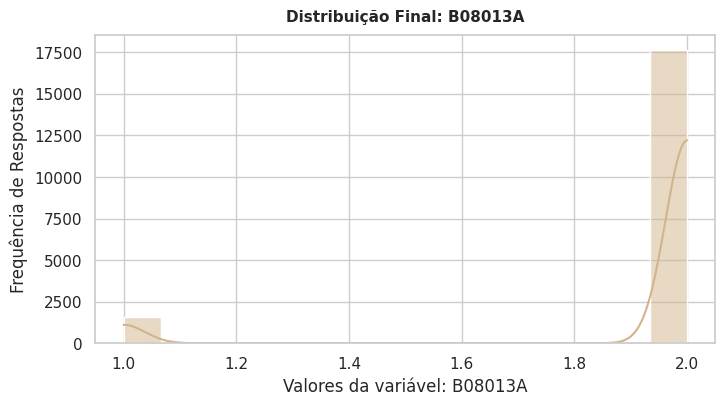

 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B08013A
Total de estudantes neste grupo extremo: 1601

>> Cruzamento com a variável: ESFERA
        Quantidade  % do Grupo
ESFERA                        
1.0           1420        88.7
0.0            181        11.3

>> Cruzamento com a variável: ANO_TURMA
                   Quantidade  % do Grupo
ANO_TURMA                                
3º Ano EM                 417        26.0
2º Ano EM                 386        24.1
1º Ano EM                 380        23.7
9º Ano EF                 193        12.1
8º Ano EF                 132         8.2
7º Ano EF                  74         4.6
1º Ano Técnico              6         0.4
3º Ano Técnico              5         0.3
2º Ano Técnico              3         0.2
2º Ano Magistério           3         0.2
3º Ano Magistério           2         0.1

>> Cruzamento com a variável: B01001A
         Quantidade  % do Grupo
B01001A                        
2.0            1601       100.0

>> Cruzamento com a vari

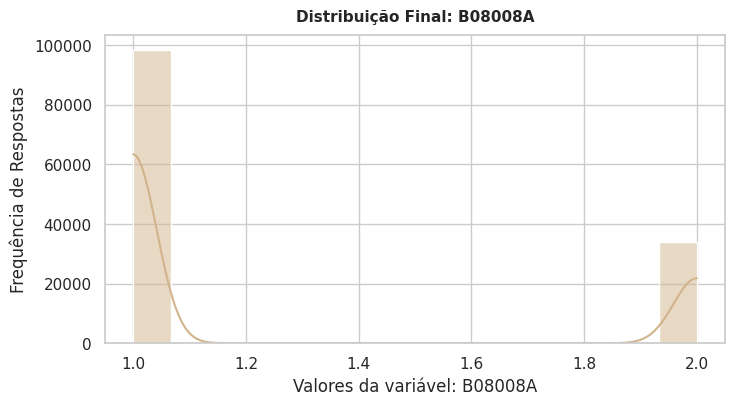

 [Estatística] Coluna 'B08008A' normalizada como 'B08008A_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B08008A
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

 Analisando variável: B08009A


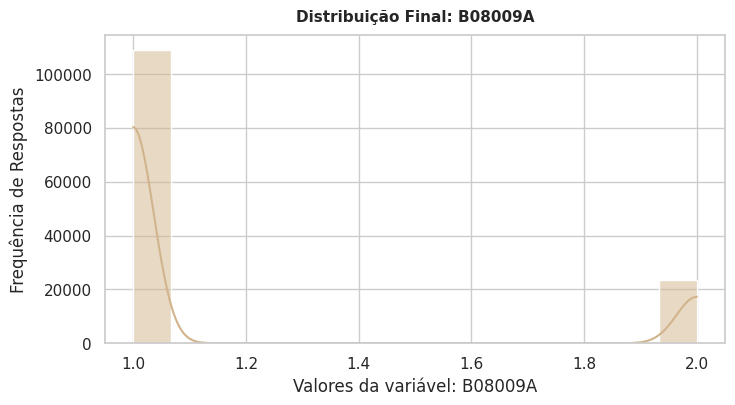

 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B08009A
Total de estudantes neste grupo extremo: 23392

>> Cruzamento com a variável: ESFERA
        Quantidade  % do Grupo
ESFERA                        
1.0          12634        54.0
0.0          10758        46.0

>> Cruzamento com a variável: ANO_TURMA
                   Quantidade  % do Grupo
ANO_TURMA                                
8º Ano EF                6939        29.7
1º Ano EM                4590        19.6
9º Ano EF                3681        15.7
7º Ano EF                3330        14.2
2º Ano EM                2384        10.2
3º Ano EM                2131         9.1
1º Ano Técnico            233         1.0
2º Ano Técnico             52         0.2
3º Ano Técnico             48         0.2
2º Ano Magistério           3         0.0
3º Ano Magistério           1         0.0

>> Cruzamento com a variável: B01001A
         Quantidade  % do Grupo
B01001A                        
2.0           11899        50.9
1.0           11419     

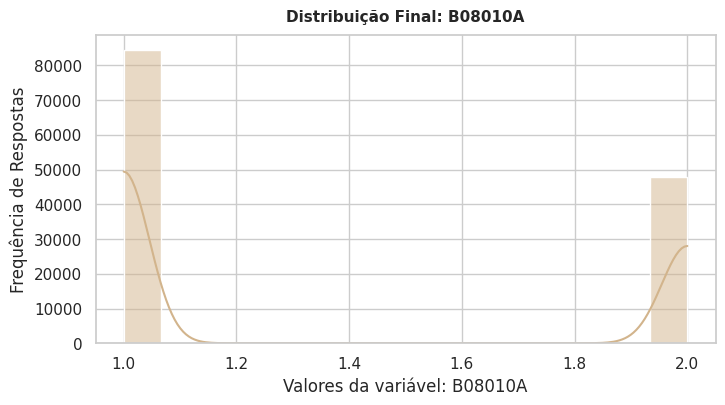

 [Estatística] Coluna 'B08010A' normalizada como 'B08010A_norm'.
 INVESTIGAÇÃO DE PERFIL: OUTLIERS DE B08010A
Total de estudantes neste grupo extremo: 0
Nenhum outlier para analisar.

--- GERANDO PAINEL CONSOLIDADO DE BOXPLOTS ---


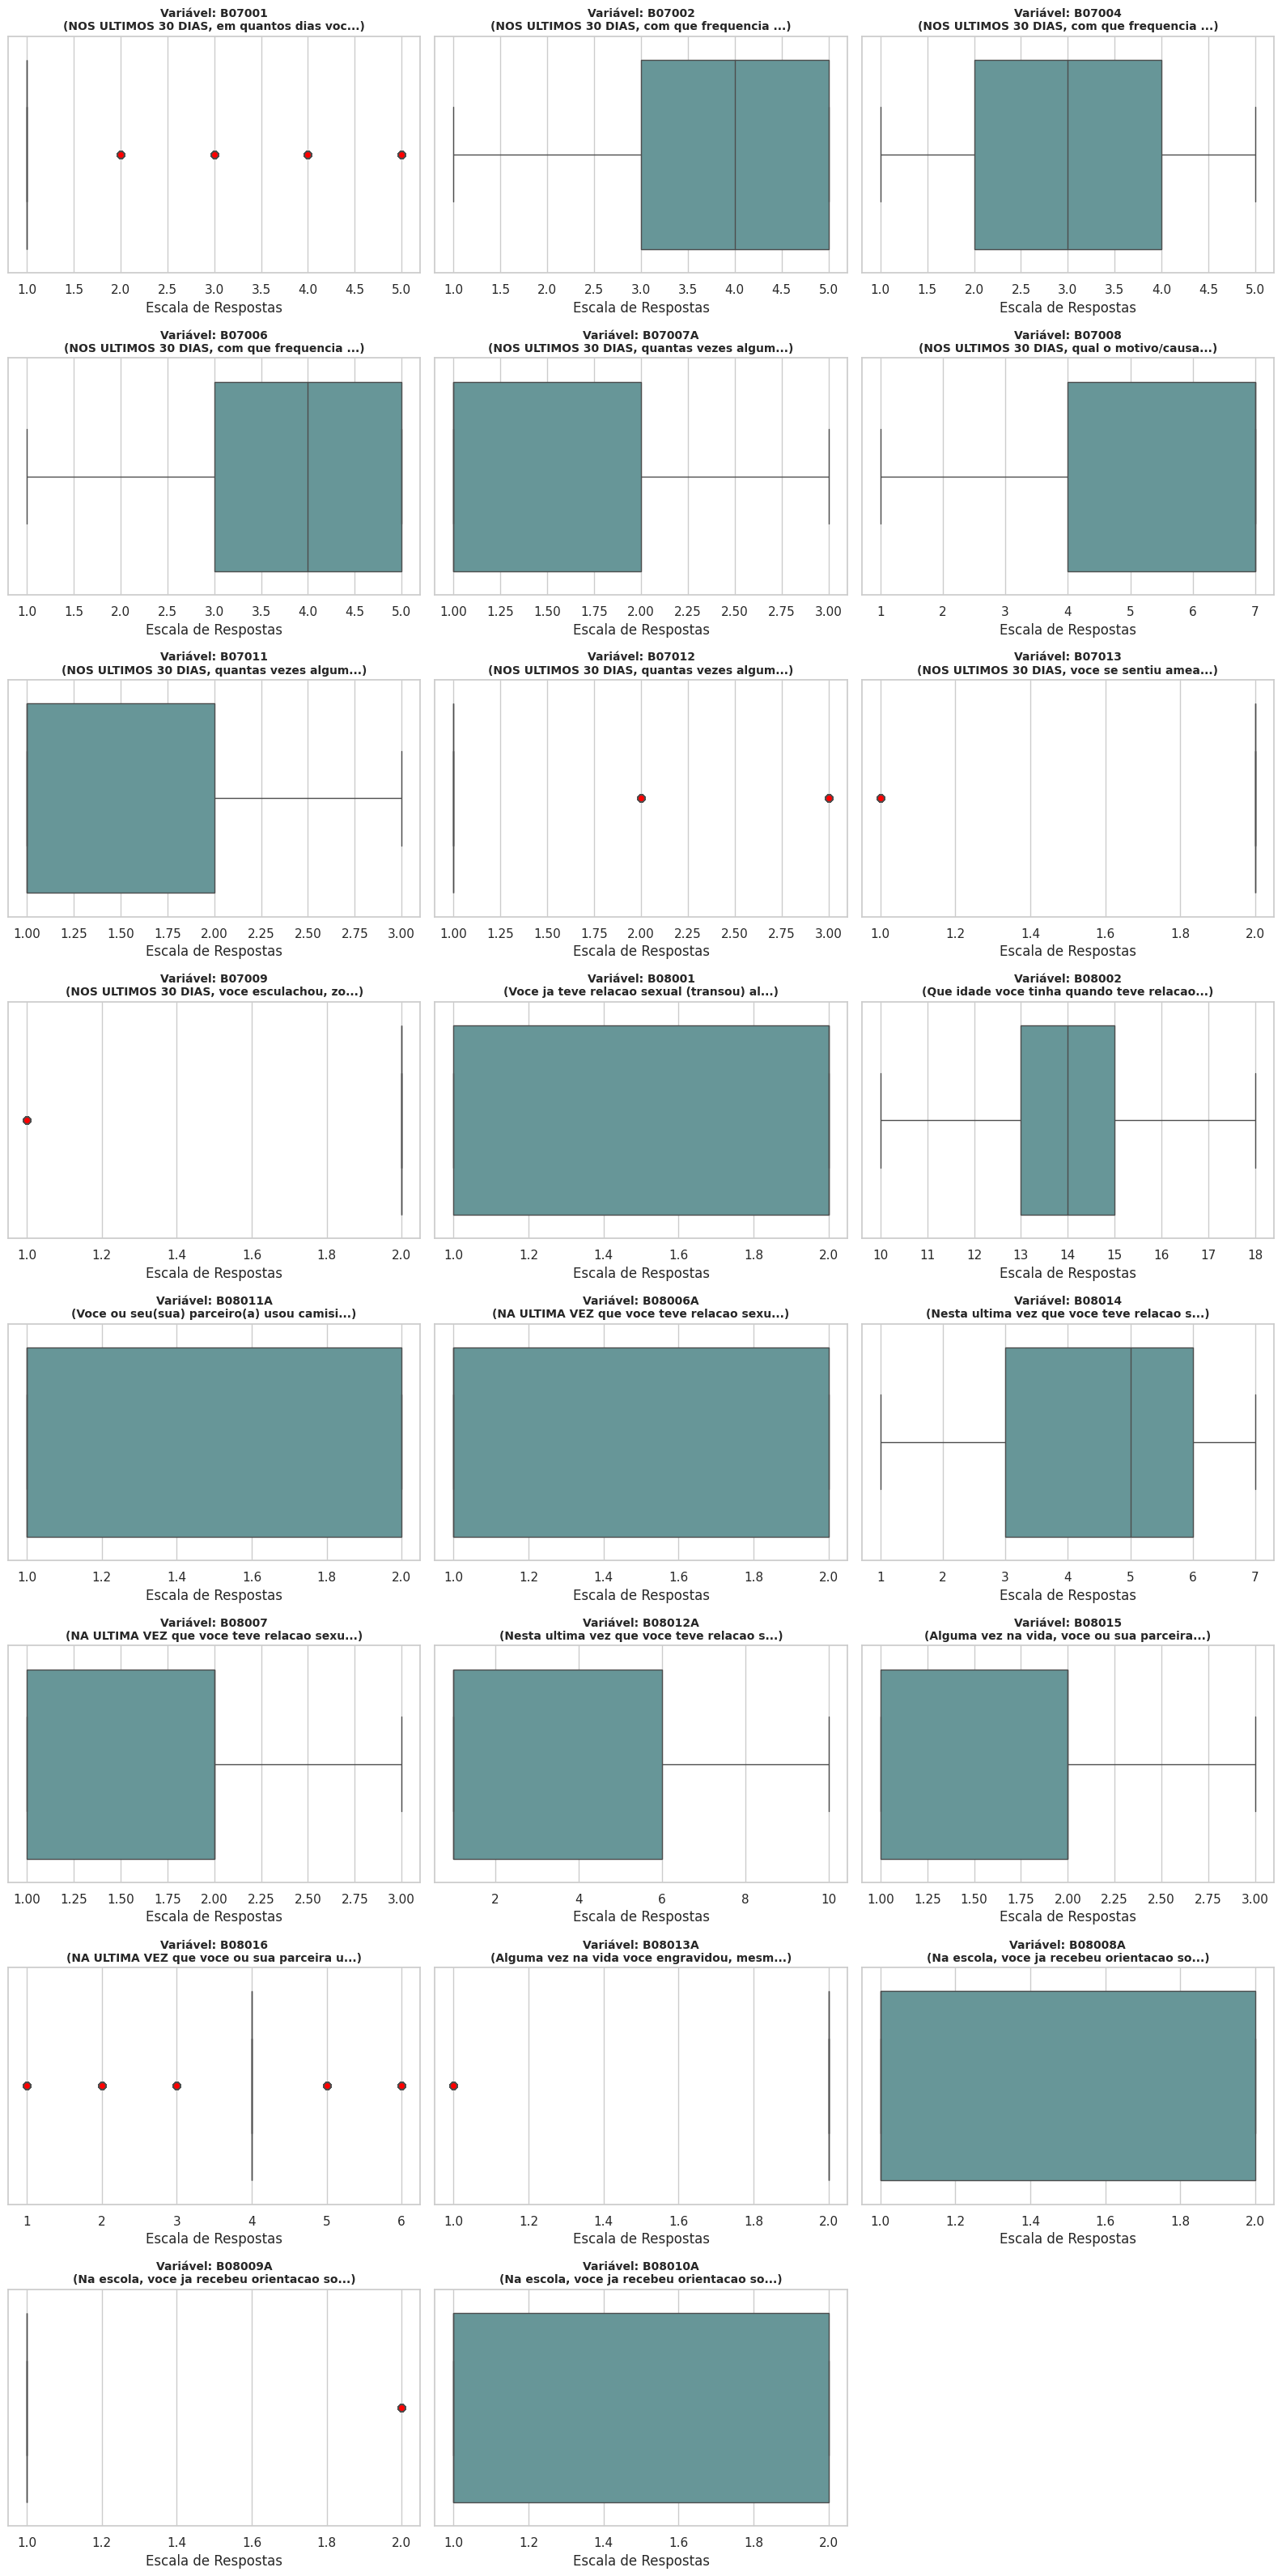


--- SALVANDO DADOS E GERANDO ARQUIVOS ---

[Escrita] Conectando ao seu Google Drive pessoal...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Salvo arquivo

 SUCESSO: Relatório estatístico automatizado salvo como 'Relatorio_Analise_PeNSE.md'.
Para visualizar o relatório no Colab, basta clicar 2x nele na aba de arquivos (ícone de pasta à esquerda).


In [ ]:
import sys
import pandas as pd

from gerenciador_de_arquivos import GerenciadorArquivos
from pense_dados import PenseDados
from pense_limpeza import PenseLimpeza
from pense_dicionario import PenseDicionario
from pense_estatistica import PenseEstatistica
from pense_visualizer import PenseVisualizer
from pense_relatorio import PenseRelatorio

try:
    blocos_para_analise = ['B07', 'B08']
    colunas_investigacao = ['ESFERA', 'ANO_TURMA', 'B01001A', 'B01006', 'B01007']
    blocos_ja_processados = []

    id_dicionario = '1IH-awunS7QIHozFdvPCUsUrwevy835ML'
    id_pense = '1CXXO4gPIP5lOqird5QeHkTrYqcyA-tD6'

    gerenciador = GerenciadorArquivos(id_pense)
    gerenciador_dicionario = GerenciadorArquivos(id_dicionario)

    df_dicionario = gerenciador_dicionario.load_data()
    df_bruto = gerenciador.load_data()

    if df_bruto is not None and len(df_bruto) > 0 and df_bruto.shape[1] > 1:

        dicionario = PenseDicionario(df_dicionario)
        visualizador = PenseVisualizer()
        estatistica = PenseEstatistica()
        relatorio = PenseRelatorio()

        print("\n--- EXECUTANDO LIMPEZA E PADRONIZAÇÃO ---")
        limpador = PenseLimpeza(df_bruto)
        df_limpo = (limpador
                    .filtrar_perfil(blocos_para_analise)
                    .padronizar_categorias_base()
                    .tratar_valores_nulos()
                    .obter_dados_tratados()
                    )

        df_processado = df_limpo.copy()

        # O Redator anota os tamanhos dos arquivos antes e depois
        relatorio.registrar_visao_geral(blocos_para_analise, df_bruto, df_processado)

        #  busca  as colunas do bloco
        col_calculos = [col for col in df_processado.columns if any(col.upper().startswith(b) for b in blocos_para_analise)]

        for col_real in col_calculos:
            significado = dicionario.obter_significado(col_real)

            print(f"\n Analisando variável: {col_real}")
            visualizador.plotar_histograma(df_processado, col_real, f"Distribuição Final: {col_real}")

            # Processamento estatístico
            df_processado = estatistica.sinalizar_outliers_iqr(df_processado, col_real)
            df_processado = estatistica.normalizar_colunas_generico(df_processado, [col_real])
            estatistica.gerar_perfil_outliers(df_processado, col_real, colunas_investigacao)

            relatorio.registrar_variavel(df_processado, col_real, significado)

        print("\n--- GERANDO PAINEL CONSOLIDADO DE BOXPLOTS ---")
        visualizador.plotar_todos_boxplots(df_processado, col_calculos, dicionario)
        print("\n--- SALVANDO DADOS E GERANDO ARQUIVOS ---")
        nome_do_resultado = 'PeNSE_2019_Pronto.csv'
        df_processado.to_csv(nome_do_resultado, index=False, encoding='utf-8')
        gerenciador.salvar_no_drive(df_processado, nome_do_resultado)


        nome_relatorio = 'Relatorio_Analise_PeNSE.md'
        relatorio.salvar_relatorio(nome_relatorio)
    else:
        raise ValueError(f"O DataFrame veio incorreto ou vazio.")

except Exception as e:
    import traceback
    print(f'\nErro no fluxo principal: {e}')
    traceback.print_exc()